## Fourier Specrum Plot

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)
img

array([[ 15,  15,  15, ...,  90, 100, 106],
       [ 15,  15,  15, ...,  90, 100, 106],
       [ 14,  15,  15, ...,  90, 100, 106],
       ...,
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  19,  19, ...,   0,   0,   0],
       [ 18,  20,  20, ...,   0,   0,   0]], shape=(635, 950), dtype=uint8)

In [3]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
mag_spc = 20 * np.log(np.abs(fshift)+1)

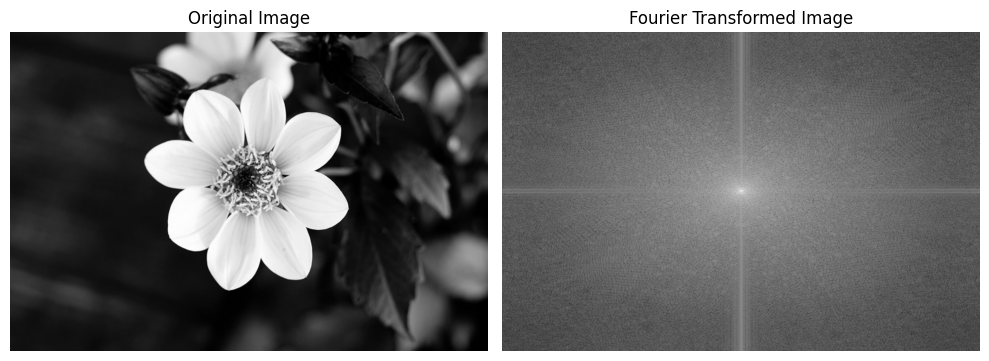

In [4]:
plt.figure(figsize = (10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mag_spc, cmap = 'gray')
plt.title('Fourier Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Ideal Lowpass Filter

In [5]:
def ideal_lowpass (shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols), dtype = np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if D <= cutoff:
                H[u,v] = 1
    return H

In [6]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)

In [7]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 100

H = ideal_lowpass(img.shape, cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

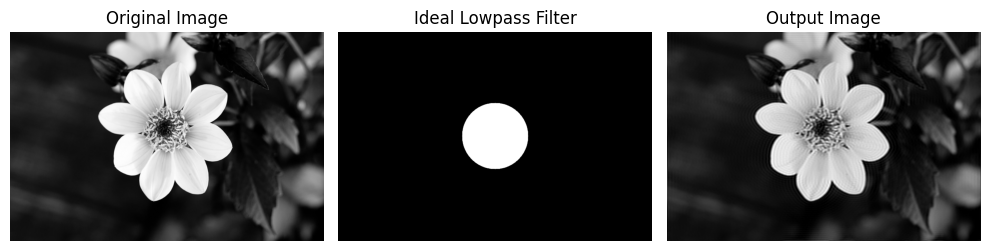

In [8]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap = 'gray')
plt.title('Ideal Lowpass Filter')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgb, cmap = 'gray')
plt.title('Output Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Gaussian Lowpass Filter

In [9]:
def gaussian_lowpass (shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols), dtype = np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            H[u,v] = np.exp(-(D**2)/(2*(cutoff**2)))
    return H

In [10]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)

In [11]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 20

H = gaussian_lowpass(img.shape, cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

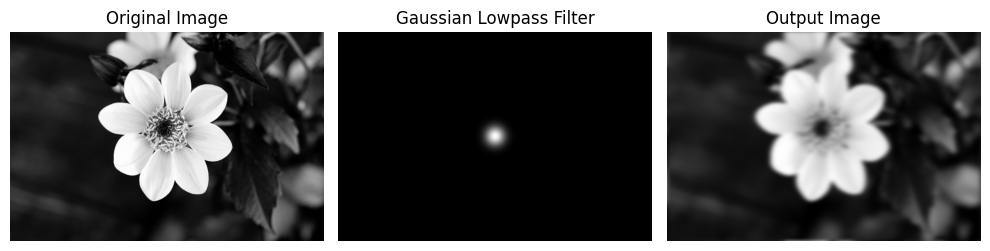

In [12]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap = 'gray')
plt.title('Gaussian Lowpass Filter')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgb, cmap = 'gray')
plt.title('Output Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Butterworth Lowpass Filter

In [13]:
def butterworth_lowpass (shape, cutoff, order):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols), dtype = np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            H[u,v] = 1 / (1+(D/cutoff)**(2*order))
    return H

In [14]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)

In [15]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 20
order = 2

H = butterworth_lowpass(img.shape, cutoff, order)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

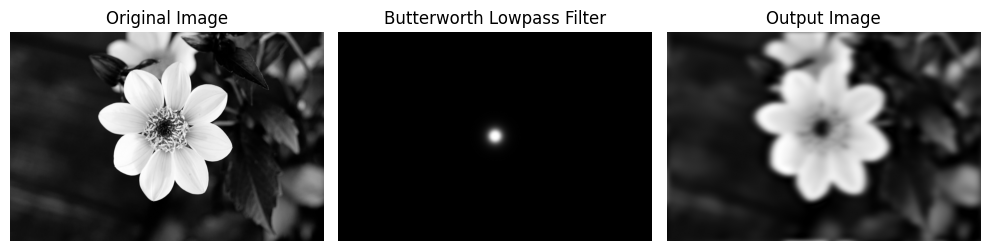

In [16]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap = 'gray')
plt.title('Butterworth Lowpass Filter')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgb, cmap = 'gray')
plt.title('Output Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Ideal Highpass Filter

In [17]:
def ideal_highpass (shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols), dtype = np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if D > cutoff:
                H[u,v] = 1
    return H

In [18]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)

In [19]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 100

H = ideal_highpass(img.shape, cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

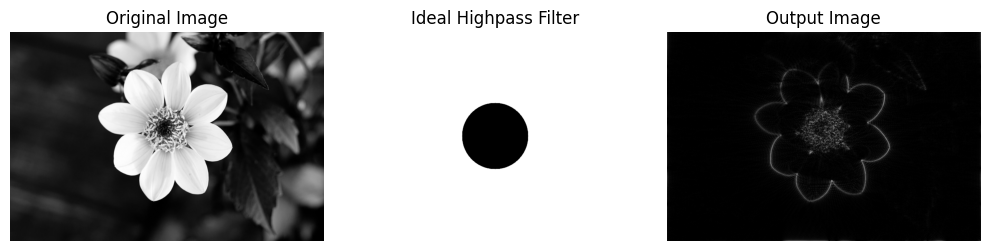

In [20]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap = 'gray')
plt.title('Ideal Highpass Filter')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgb, cmap = 'gray')
plt.title('Output Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Gaussian Highpass Filter

In [21]:
def gaussian_highpass (shape, cutoff):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols), dtype = np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            H[u,v] = 1 - np.exp(-(D**2)/(2*(cutoff**2)))
    return H

In [22]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)

In [23]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 20

H = gaussian_highpass(img.shape, cutoff)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

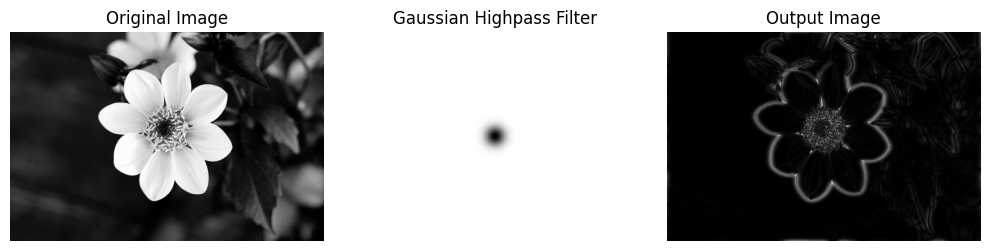

In [24]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap = 'gray')
plt.title('Gaussian Highpass Filter')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgb, cmap = 'gray')
plt.title('Output Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Butterworth Highpass Filter

In [25]:
def butterworth_highpass (shape, cutoff, order):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    H = np.zeros((rows,cols), dtype = np.float32)
    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if D == 0: #avoid division by zero
                H[u,v]=0
            else:
                H[u,v] = 1 / (1+(cutoff/D)**(2*order))
    return H

In [26]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)

In [27]:
dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

cutoff = 20
order = 2

H = butterworth_highpass(img.shape, cutoff, order)

H3ch = H[:,:,np.newaxis]

filtered = dft_shift * H3ch

f_ishift = np.fft.ifftshift(filtered)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

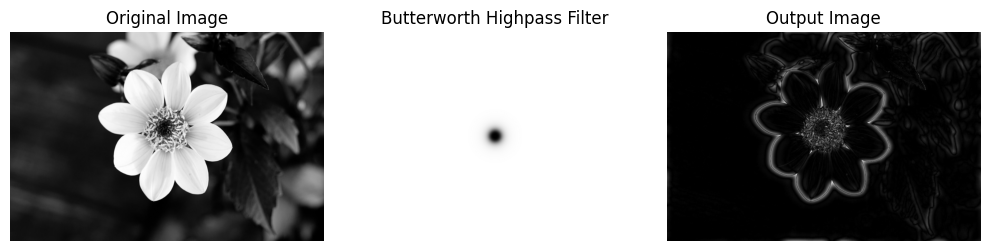

In [28]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap = 'gray')
plt.title('Butterworth Highpass Filter')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(imgb, cmap = 'gray')
plt.title('Output Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Laplacian in Frequency Domain

In [31]:
img = cv2.imread('flower.jpg',cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256,256))

In [32]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2

dft = cv2.dft(np.float32(img), flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

u = np.arange(rows)
v = np.arange(cols)

U,V = np.meshgrid(u-crow, v-ccol,  indexing = 'ij')
D = -(4 * np.pi**2) * (U**2 + V**2)
laplacian_filter = np.zeros((rows, cols, 2), dtype = np.float32)
laplacian_filter[:,:,0] = D
laplacian_filter[:,:,1] = D

filtered_dft = dft_shift * laplacian_filter

f_ishift = np.fft.ifftshift(filtered_dft)
imgb = cv2.idft(f_ishift)
imgb = cv2.magnitude(imgb[:,:,0],imgb[:,:,1])
imgb = cv2.normalize(imgb, None, 0, 255, cv2.NORM_MINMAX)
imgb = np.uint8(imgb)

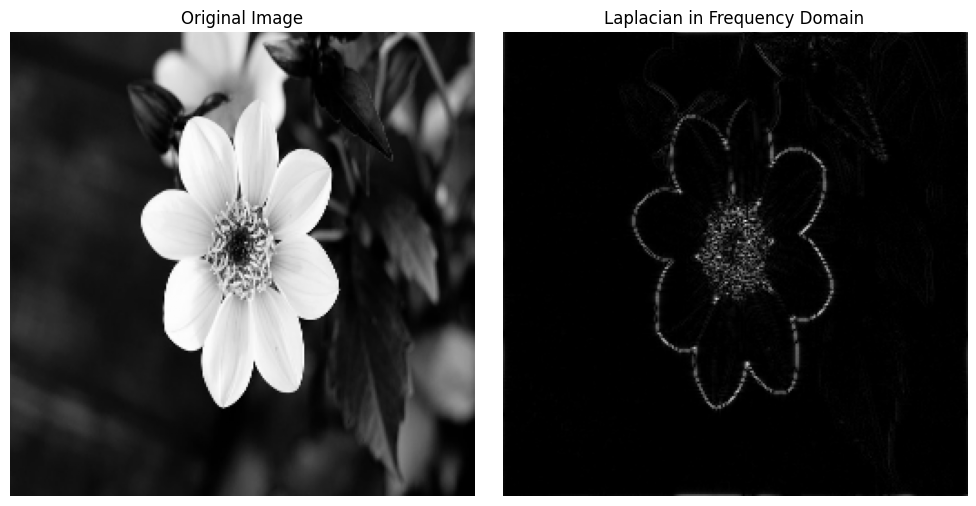

In [33]:
plt.figure(figsize = (10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap = 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imgb, cmap = 'gray')
plt.title('Laplacian in Frequency Domain')
plt.axis('off')

plt.tight_layout()
plt.show()